In [2]:
# IMPORTS
from scipy.io import loadmat
# Load the .mat file
data = loadmat('Data.mat')

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt

import tensorflow as tf
from sklearn.metrics import (average_precision_score)
from sklearn.model_selection import LeaveOneGroupOut

In [3]:
# Extract signal data 
humidity = data['Humedad'].flatten() # Save the humidity data in a 1D array
humidity = humidity[~np.isnan(humidity)] # Remove NaNs

# Filter signal and get its first "derivative"
prev_mean = np.mean(humidity[0:5]) # Mean with the first 5 points
diff_mean_hum = []

for i in range(5, len(humidity)): 
	new_mean = prev_mean + (humidity[i] - humidity[i - 5]) / 5
	if i > 5:
		diff_mean_hum.append(new_mean - prev_mean) # ΔHumidity (5-point moving mean)
	prev_mean = new_mean

In [4]:
# Plot 1: Raw relative humidity signal
fig1 = go.Figure()
fig1.add_trace(go.Scatter(y=humidity, mode='lines', name='Humidity'))
fig1.update_layout(title='Raw relative humidity signal', xaxis_title='Sample', yaxis_title='Relative humidity (%)')
fig1.show()

# Plot 2: First "derivative" of 5-point moving average
fig2 = go.Figure()
fig2.add_trace(go.Scatter(y=diff_mean_hum, mode='lines', name='ΔHumidity (Moving Avg Diff)'))
fig2.update_layout(title='Difference between 5-point moving averages', xaxis_title='Sample', yaxis_title='ΔHumidity')
fig2.show()

In [ ]:
diff_peak_locs = [344, 514, 843, 1166, 1504, 1691, 2030, 2362, 2690, 3035, 3380, 3988] # Peak onsets, not centered

# Plot 3: First "derivative" of 5-point moving average + peaks
fig3 = go.Figure()
fig3.add_trace(go.Scatter(y=diff_mean_hum, mode='lines', name='ΔHumidity (Moving Avg Diff)'))
fig3.update_layout(title='Difference between 5-point moving averages', xaxis_title='Sample', yaxis_title='ΔHumidity')
for loc in diff_peak_locs:
    fig3.add_vline(x=loc, line_width=1, line_dash='dash', line_color='black')
fig3.show()

In [6]:
# ---Extract peak windows---

window_len = 11
max_offset = window_len // 2
offsets = np.arange(-(max_offset), (max_offset) + 1) # All offset positions for a peak location
print("Offsets =", offsets)
diff_mean_hum = np.array(diff_mean_hum) # To NumPy array so that it accepts NP's arrays of indices 

# Save peak windows in a matrix (each window in a row)
len_diff_mean = len(diff_mean_hum)
peak_window_locs = []
peak_windows_mx = []

for loc in diff_peak_locs: # for each peak location
	if loc - max_offset >= 0 and loc + max_offset + 1 < len_diff_mean:
	# If the offsets are inside the diff_meam signal
		signal_window = diff_mean_hum[loc + offsets] # e.g. loc = 5 -> 5 + [-1,0,1] = [4,5,6]
		peak_windows_mx.append(signal_window)
		peak_window_locs.append(loc + offsets)
pos_inputs = np.vstack(peak_windows_mx)
print("Indices of the 1st peak window:", peak_window_locs[1])
print("Positive windows shape:", pos_inputs.shape) # Should be 12 rows (peaks), 11 columns (values per peak window)

Offsets = [-5 -4 -3 -2 -1  0  1  2  3  4  5]
Indices of the 1st peak window: [509 510 511 512 513 514 515 516 517 518 519]
Positive windows shape: (12, 11)


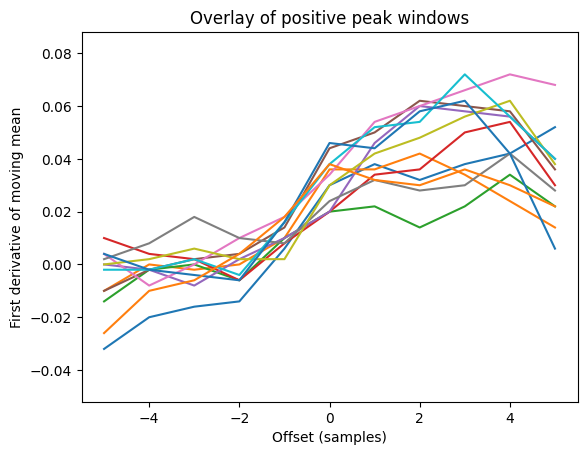

In [7]:
# Plot 4: Peak windows
plt.figure()
for window in pos_inputs:
    plt.plot(offsets, window)
plt.xlabel("Offset (samples)")
plt.ylabel("First derivative of moving mean")
plt.title("Overlay of positive peak windows")

min_diff = min(diff_mean_hum)
max_diff = max(diff_mean_hum)

plt.ylim(min_diff, max_diff)

plt.show()

In [8]:
# ---Extract negative windows---

# Boolean "peaks_mask" with the samples inside a peak window
peaks_mask = np.zeros(len_diff_mean, dtype=bool)
for window in peak_window_locs:
	# "window" is an array containing the sample numbers of each peak window

	# Add a 90 sample time-out after a peak 
	last_window_value = window[window_len - 1] 
	time_out_limit = last_window_value - max_offset + 90
	timed_out_window = np.concatenate([window, np.arange(last_window_value + 1, time_out_limit)])

	# Mark each sample inside a peak window (and the time-out range) as "True"
	peaks_mask[timed_out_window] = True 


# Gather all valid centers whose 11-sample slice does NOT touch a positive window
all_centers = np.arange(max_offset, len_diff_mean - max_offset)
neg_centers = []
for center in all_centers:
	window_locs = center + offsets
	if not peaks_mask[window_locs].any():
	# If there's no "True" in that window // if the window doesn't overlap
		neg_centers.append(center)

print(f"Total windows: {len(all_centers)}")
print(f"Non-overlapping negative windows: {len(neg_centers)}")

# Sample random negative windows
num_pos = len(peak_window_locs)
num_neg = 15 * num_pos # x15 more negatives than positives
rng = np.random.default_rng(42)
random_neg_centers = rng.choice(neg_centers, size=num_neg, replace=False)

neg_windows_mx = []

for center in random_neg_centers:
	signal_window = diff_mean_hum[center + offsets]
	neg_windows_mx.append(signal_window)
neg_inputs = np.vstack(neg_windows_mx)
print("Negative windows shape:", neg_inputs.shape) # Should be 180 rows (negative windows), 11 columns (values per window)


Total windows: 4154
Non-overlapping negative windows: 2894
Negative windows shape: (180, 11)


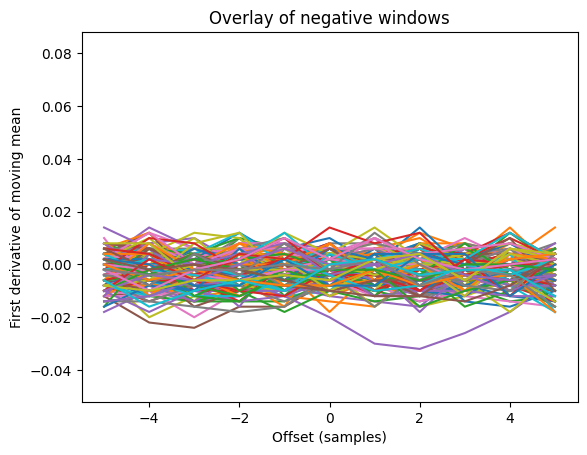

In [9]:
# Plot 5: Negative windows
plt.figure()
for window in neg_inputs:
    plt.plot(offsets, window)
plt.xlabel("Offset (samples)")
plt.ylabel("First derivative of moving mean")
plt.title("Overlay of negative windows")
plt.ylim(min_diff, max_diff)
plt.show()

In [ ]:
# ---Build feature matrix---

# Stack the positive and negative windows matrices
X_raw = np.vstack([pos_inputs, neg_inputs]) # Raw signal windows matrix (not featurized)

# Labels vector
y = np.concatenate([
	np.ones(pos_inputs.shape[0], dtype=int), # Vector with 1s. # of 1s = # of peak windows
	np.zeros(neg_inputs.shape[0], dtype=int) # Vector with 0s. # of 0s = # of negative windows
])

# Extract features from each window
def featurize(window):
	# Take a signal window and return an array with features from that window
	feats = []
	# Statistics
	feats.append(window.mean())					# mean
	feats.append(window.std())					# standard deviation
	feats.append(window.max() - window.min())	# peak-to-peak difference

	feats.append(np.argmax(window))				# position of the highest value
		# positive windows have a centered max value, negative - not necessarily
	
	# Spectral features (Fourier transform)
	fft = np.fft.rfft(window)
	feats.extend(np.abs(fft[1:3])) # "abs" because the result has imaginary numbers
		# "extend" to add each value individually to the array
		# first 2 frequency bins beacause peaks span a few samples (higher frequency)
	return np.array(feats)

# Feature matrix (X - model inputs)
feature_list = []
for window in X_raw:
	features = featurize(window)
	feature_list.append(features)

X = np.vstack(feature_list)

print("Features matrix shape:", X.shape) # Should be:
	# 192 rows: positive + negative windows
	# 6 columns: # of extracted features

Features matrix shape: (192, 6)


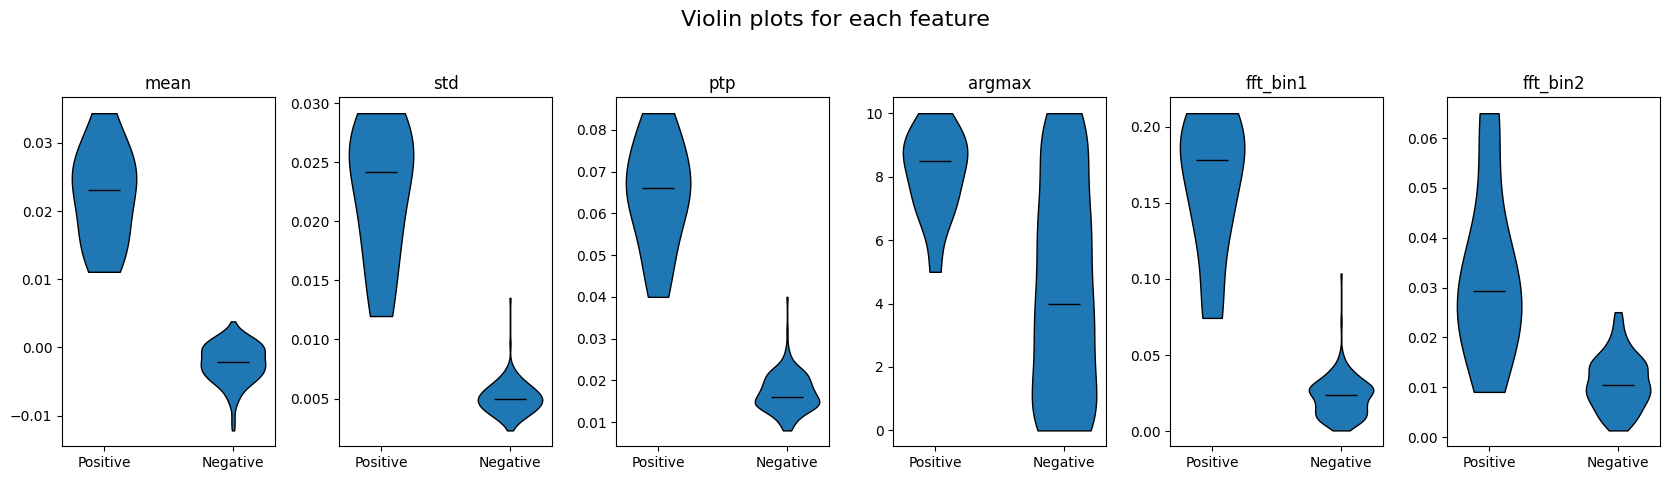

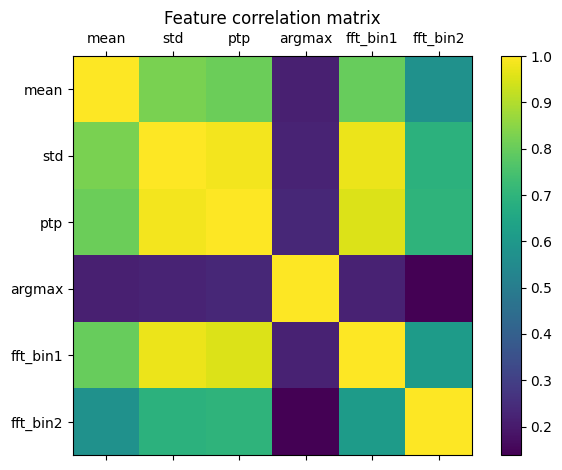

In [11]:
# ---Exploratory data analysis---

# Violin plots for each feature
feature_names = ['mean', 'std', 'ptp', 'argmax', 'fft_bin1', 'fft_bin2']

n_features = X.shape[1]
fig, axes = plt.subplots(1, n_features, figsize=(2.8*n_features, 5), sharey=False)

for i, ax in enumerate(axes):
    data_pos = X[y == 1, i]
    data_neg = X[y == 0, i]
    parts = ax.violinplot([data_pos, data_neg], 
                          showmedians=True,
                          showextrema=False)
    
	# Style the median lines
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(1)
    
    # Style the violin bodies
    for body in parts['bodies']:
        body.set_alpha(1.0) 
        body.set_edgecolor('black')
        body.set_linewidth(1.0)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Positive', 'Negative'])
    ax.set_title(feature_names[i])

fig.suptitle('Violin plots for each feature', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Correlation matrix
df = pd.DataFrame(X, columns = feature_names)
corr = df.corr()
fig, ax = plt.subplots()
cax = ax.matshow(corr)
fig.colorbar(cax)
ax.set_xticks(range(len(feature_names)))
ax.set_yticks(range(len(feature_names)))
ax.set_xticklabels(feature_names)
ax.set_yticklabels(feature_names)
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.show()

In [12]:
# ---Normalize each feature---

# Mean of each column (feature)
feature_means = X.mean(axis=0) # feature_means[i] is the mean of feature i

# Sample std of each column (feature)
feature_stds = X.std(axis=0, ddof=1) # feature_stds[i] is the sample std of feature i

# Z-score feature matrix
X_norm = (X - feature_means) / feature_stds
# NumPy does this for each column of X:
#	e.g. subtracts the *first* mean from the values in the *first* column of X


In [13]:
# --- Leave one group out (LOGO) ---

def build_model(input_dim):
    # Build a logistic regression model: takes (input_dim) number of features and outputs a probability
	model = tf.keras.Sequential([
		tf.keras.layers.Input((input_dim,)),
		tf.keras.layers.Dense(
			1, # 1 output neuron
			activation = 'sigmoid', # Sigmoid activation function -> probability output
			kernel_regularizer = tf.keras.regularizers.l2(1e-4), # Avoid too high weight values (memorization)
			kernel_initializer = tf.keras.initializers.GlorotUniform(seed=42), # Start with the same weights
			bias_initializer = tf.keras.initializers.Zeros() # Set starting bias to 0
		)
	])
	return model

# LOGO traning & evaluation function
def logo_train_eval(feature_mx, labels, group_ids, initial_weights, shuffle):
	average_precision_vals  = [] # Use the "average precision" metric to evaluate the models
	all_preds = []
	all_labels = []

	# Correct weights for imbalance between # negatives and positives
	pos_weight = num_neg / num_pos
	loss_weights = (np.where(labels == 1, pos_weight, 1.0))
	#	If a window is positive (label == 1), the loss function is multiplied by "pos_weight", if not: 1.0

	for fold, (train_idx, test_idx) in enumerate(logo.split(feature_mx, labels, group_ids)):
		# Quick sanity check: both classes are present
		n_pos = int(labels[test_idx].sum())
		n_neg = (labels[test_idx] == 0).sum()
		print(f"Fold {fold:2d}: # positive windows = {n_pos}, # negative windows = {n_neg}")

		# Split
		X_train, X_test = feature_mx[train_idx], feature_mx[test_idx]
		y_train, y_test = labels[train_idx], labels[test_idx]

		# Skip folds with all 0s or all 1s if the labels are shuffled
		if shuffle == True and (y_test.sum() == 0 or y_test.sum() == len(y_test)):
			print("\tFold skipped\n")
			continue

		# Reset the model parameters
		model.set_weights(initial_weights)

		# Apply loss weights to corresponding training samples
		sample_weights_train = loss_weights[train_idx]

		# Train the model
		early_stop = tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
		#	Monitor validation set loss, if it doesn't improve for 5 consecutive epochs, stop and retrieve the best parameters

		model.fit(X_train, y_train,
				sample_weight=sample_weights_train,
				epochs=100,
				batch_size=16,
				validation_split=0.1, # 10% of the training set used for validation and early stopping checks
				callbacks=[early_stop],
				verbose=0)

		# Run the model to predict if the held-out windows are positive or negative
		y_pred = model.predict(X_test).ravel() # .ravel to convert into a list of probabilities
		all_preds.append(y_pred)
		all_labels.append(y_test)

		# For each model/LOGO run, compare labels to predictions and get the average precision
		ap = (average_precision_score(y_test, y_pred))
		print(f"Average precision (AP): {ap:.3f}\n")
		average_precision_vals.append(ap)
		
	aps = average_precision_vals
	print(f"LOGO mean AP: {np.mean(aps):.3f} ± {np.std(aps):.3f}")
	return all_preds, all_labels

# Build and compile the model
model = build_model(X_norm.shape[1]) # X_norm.shape[1]: number of columns (features)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='binary_crossentropy')

# Save the initial model parameters
initial_weights = model.get_weights()

# Set aside for testing a random set of negative windows for each positive windows
shuffled_neg_idxs = rng.permutation(num_neg) # Randomize the order of negative windows: [0, ..., 179] -> random
idxs_sets = np.array_split(shuffled_neg_idxs, num_pos) # 180 / 12 = 15 random sets of negative windows
#		12 sets of indices (one set for each positive window)
# 	Assign each set of indices a number from 0 to 11 (link negative windows to a positive one)
neg_group_ids = np.zeros(num_neg, dtype=int)
for i, idx_set in enumerate(idxs_sets):
	neg_group_ids[idx_set] = i
#	e.g., i = 0, idxs_sets[0] = [3, 17, 25] -> neg_group_ids[3], [17] and [25] = 0
#	The negative windows 3, 17 and 25 have been linked to the positive window "0"

pos_group_ids = np.arange(num_pos) # Assign a number from 0 to 11 to each positive window
groups = np.concatenate([pos_group_ids, neg_group_ids])

logo = LeaveOneGroupOut() # 1 group (positive window) as test, the other groups for training

In [14]:
# --- Train & evaluate models w/ label shuffling to check for leakage ---

average_precision_vals  = []
y_shuff = rng.permutation(y)

all_preds, all_labels = logo_train_eval(X_norm, y_shuff, groups, initial_weights, shuffle = True)

Fold  0: # positive windows = 0, # negative windows = 16
	Fold skipped

Fold  1: # positive windows = 1, # negative windows = 15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Average precision (AP): 0.100

Fold  2: # positive windows = 1, # negative windows = 15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Average precision (AP): 0.067

Fold  3: # positive windows = 0, # negative windows = 16
	Fold skipped

Fold  4: # positive windows = 0, # negative windows = 16
	Fold skipped

Fold  5: # positive windows = 2, # negative windows = 14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Average precision (AP): 0.225

Fold  6: # positive windows = 0, # negative windows = 16
	Fold skipped

Fold  7: # positive windows = 2, # negative windows = 14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Average precision (AP): 0.600

Fold  8: # positive windows = 1, # negative windows = 15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Average precision (AP): 0.500

Fold  9: # positive windows = 2, # negative windows = 14
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [15]:
# Train and evaluate models
all_preds, all_labels = logo_train_eval(X_norm, y, groups, initial_weights, shuffle = False)

Fold  0: # positive windows = 1, # negative windows = 15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Average precision (AP): 1.000

Fold  1: # positive windows = 1, # negative windows = 15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Average precision (AP): 1.000

Fold  2: # positive windows = 1, # negative windows = 15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Average precision (AP): 1.000

Fold  3: # positive windows = 1, # negative windows = 15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Average precision (AP): 1.000

Fold  4: # positive windows = 1, # negative windows = 15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Average precision (AP): 1.000

Fold  5: # positive windows = 1, # negative windows = 15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Average precision (AP): 1.000

Fold  6: # positive windows = 1, # negative windows = 15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Average precision (AP): 1.000

Fold  7: # positive windows = 1, # negative windows = 15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Average precision (AP):

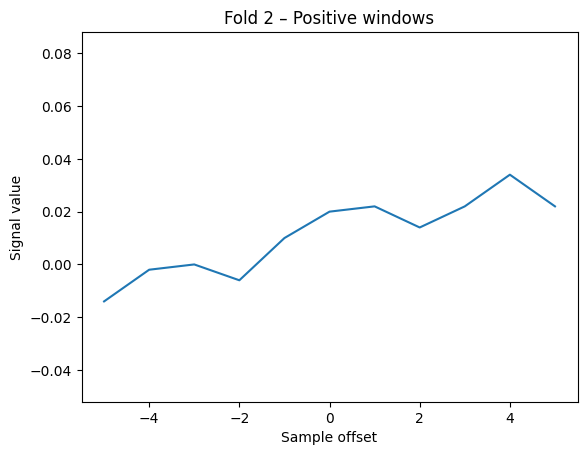

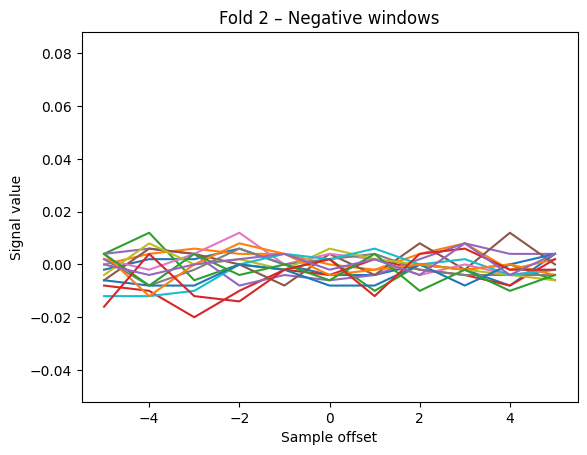

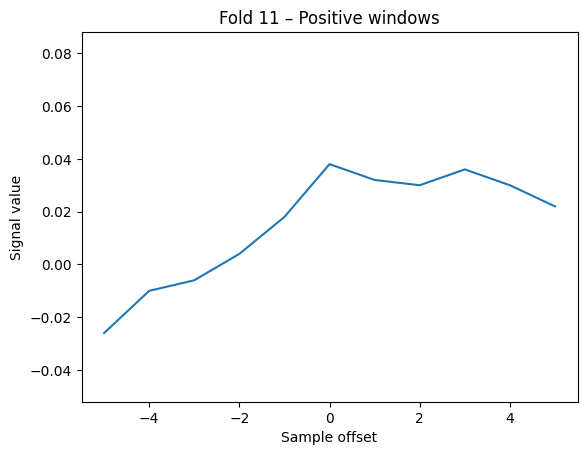

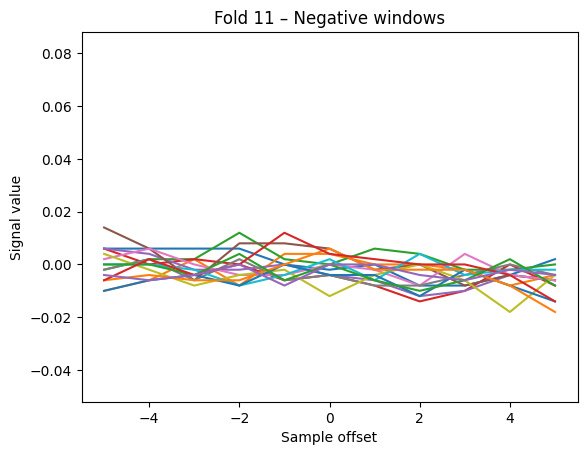

In [ ]:
# --- Plot signal windows used in the LOGO folds ---
def plot_fold_windows(fold_numbers, X_raw, y, groups, logo, offsets):
    """
    Plot raw signal windows for the specified folds.
    
    fold_numbers: list of fold indices to plot (0-based)
    X_raw:   signal windows matrix
    y:       label vector (1=pos, 0=neg)
    groups:  LOPO group ids
    logo:    LeaveOneGroupOut() instance
    offsets: 1D array of length window_len (e.g. [-5..+5])
    """
    for fold in fold_numbers:
        # Find the fold's train/test indices
        for idx, (train_idx, test_idx) in enumerate(logo.split(X_raw, y, groups)):
            if idx != fold:
                continue

            pos_idx = test_idx[y[test_idx] == 1]
            neg_idx = test_idx[y[test_idx] == 0]

            # Positive windows
            plt.figure()
            for w in X_raw[pos_idx]:
                plt.plot(offsets, w)
            plt.title(f'Fold {fold} – Positive window')
            plt.xlabel('Sample offset')
            plt.ylabel('Signal value')
            plt.ylim(min_diff, max_diff)
            plt.show()

            # Negative windows
            plt.figure()
            for w in X_raw[neg_idx]:
                plt.plot(offsets, w)
            plt.title(f'Fold {fold} – Negative windows')
            plt.xlabel('Sample offset')
            plt.ylabel('Signal value')
            plt.ylim(min_diff, max_diff)
            plt.show()

plot_fold_windows([2, 11], X_raw, y, groups, logo, offsets)

In [ ]:
# --- Get optimal probability threshold for the final model ---

from sklearn.metrics import precision_recall_curve

#all_labels = np.concatenate(all_labels)
all_probs = np.concatenate(all_preds)

precision, recall, thresholds = precision_recall_curve(all_labels, all_probs)
f1_scores = 2 * (precision * recall) / (precision + recall)
best_idx = np.argmax(f1_scores)
best_threshold = round(thresholds[best_idx], 5)

print("Best threshold:", best_threshold)
print(f"Best recall: {(recall[best_idx]):.3f}")
print(f"Best precision: {(precision[best_idx]):.3f}")
print(f"Best F1-score: {(f1_scores[best_idx]):.3f}")

Best threshold: 0.77389
Best recall: 1.000
Best precision: 0.923
Best F1-score: 0.960


In [20]:
# --- Prepare data for the final model ---

# 1) Use all the negative windows
neg_windows_mx = []
for center in neg_centers:
	signal_window = diff_mean_hum[center + offsets]
	neg_windows_mx.append(signal_window)
neg_inputs = np.vstack(neg_windows_mx)
print("Negative windows shape:", neg_inputs.shape)

# 2) Build final feature matrix
# Stack the positive and negative windows matrices
X_raw_final = np.vstack([pos_inputs, neg_inputs]) # Raw signal windows matrix (not featurized)

# Final labels vector
y_final = np.concatenate([
	np.ones(pos_inputs.shape[0], dtype=int), # Vector with 1s. # of 1s = # of peak windows
	np.zeros(neg_inputs.shape[0], dtype=int) # Vector with 0s. # of 0s = # of negative windows
])

# Feature matrix (X - model inputs)
feature_list = []
for window in X_raw_final:
	features = featurize(window)
	feature_list.append(features)

X_final = np.vstack(feature_list)

print("Features matrix shape:", X_final.shape) # Should be:
	# 2904 rows: positive + negative windows
	# 6 columns: # of extracted features

# 3) Normalize each feature
# Mean of each column (feature)
feature_means = X_final.mean(axis=0) # feature_means[i] is the mean of feature i

# Sample std of each column (feature)
feature_stds = X_final.std(axis=0, ddof=1) # feature_stds[i] is the sample std of feature i

# Z-score feature matrix
X_final_norm = (X_final - feature_means) / feature_stds
# NumPy does this for each column of X:
#	e.g. subtracts the *first* mean from the values in the *first* column of X

Negative windows shape: (2894, 11)
Features matrix shape: (2906, 6)


In [28]:
# --- Build and train the final model ---

final_model = build_model(X_final_norm.shape[1]) # Model that takes 6 features
final_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='binary_crossentropy')

initial_weights_final = final_model.get_weights()

pos_weight = neg_inputs.shape[0] / num_pos
loss_weights = (np.where(y_final == 1, pos_weight, 1.0))

early_stop = tf.keras.callbacks.EarlyStopping(
	monitor='loss', # Track training loss instead of validation
	patience=5,
	restore_best_weights=True)

# Train the model using all available data (no validation set, LOGO already used for validation)
final_model.fit(
	X_final_norm, y_final,
	sample_weight = loss_weights,
	epochs=100,
	batch_size=16,
	callbacks=[early_stop],
	verbose=0)

final_weights = final_model.get_weights()

In [57]:
# --- Apply the model to the full signal ---

def normalize_n_reshape(window_features):
	# Normalize features of a window using the overall means and stds
	norm_feat_window = (window_features - feature_means) / feature_stds
	return norm_feat_window.reshape(1, -1) # The model expects a 1x6 mx; 1: 1 row; -1: # columns = # elements


peak_centers = []
win_center = 15
while win_center < len_diff_mean - max_offset:	
	signal_window = diff_mean_hum[win_center + offsets]
	win_features = featurize(signal_window)
	feats_batch = normalize_n_reshape(win_features)

	pos_prob = final_model.predict(feats_batch, verbose=0)[0,0]
	#	.predict returns a 2D array, the position [0, 0] stores the probability value

	if pos_prob >= best_threshold: # If a peak is detected
		peak_centers.append(win_center) # Store the peak position
		win_center = win_center + 90 # Stop detections for 90 samples (avoid repeated positives)
	else:
		win_center = win_center + 1


In [59]:
print("Ground-truth peak positions:", diff_peak_locs)
print("Model-detected peak positions:", peak_centers)

Ground-truth peak positions: [344, 514, 843, 1166, 1504, 1691, 2030, 2362, 2690, 3035, 3380, 3988]
Model-detected peak positions: [340, 510, 842, 1163, 1500, 1686, 2026, 2359, 2686, 3031, 3375, 3983]


In [ ]:
# --- Evaluate the results ---

# Inputs:
true_peaks     = np.array(diff_peak_locs)   # ground-truth positions
detected_peaks = np.array(peak_centers)     # model’s output positions
tol = 5                                     # ±5-sample tolerance

# 2) Count true positives (TP): 
#    a true peak is a TP if there exists at least one detected peak within +-tol.
tp = 0
matched = []  # Keep track of which detected peaks have been matched
for p in true_peaks:
    dists = np.abs(detected_peaks - p) # Distances to all detected peaks
    idx = np.where(dists <= tol)[0] # Find peaks within tolerance
    if idx.size > 0:
        tp = tp + 1
        # mark the *first* matching detection as used
        matched.append(idx[0])

# 3) False negatives (FN): ground-truth peaks missed
fn = len(true_peaks) - tp

# 4) False positives (FP): detected peaks not matched
#    total detections minus those matched to a true peak
fp = len(detected_peaks) - len(set(matched))

# 5) Compute precision, recall, F1
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

print(f"TP = {tp}, FP = {fp}, FN = {fn}")
print(f"Precision = {precision:.3f}")
print(f"Recall    = {recall:.3f}")
print(f"F1-score  = {f1:.3f}")

TP = 12, FP = 0, FN = 0
Precision = 1.000
Recall    = 1.000
F1-score  = 1.000


In [ ]:
# First "derivative" of 5-point moving average + peaks + detected peaks
fig4 = go.Figure()
fig4.add_trace(go.Scatter(y=diff_mean_hum, mode='lines', name='ΔHumidity (Moving Avg Diff)'))

# Traces for legend
fig4.add_trace(go.Scatter(x=[None], y=[None], mode='lines', line=dict(color='black', dash='dash'), name='Ground-truth peaks'))
fig4.add_trace(go.Scatter(x=[None], y=[None], mode='lines', line=dict(color='red', dash='dash'), name='Detected peaks'))

fig4.update_layout(title='Difference between 5-point moving averages', xaxis_title='Sample', yaxis_title='ΔHumidity',
				       legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right',x=1))

for loc in diff_peak_locs:
	fig4.add_vline(x=loc, line_width=.5, line_dash='dash', line_color='black')
for loc in peak_centers:
	fig4.add_vline(x=loc, line_width=.5, line_dash='dash', line_color='red')

fig4.show()

In [66]:
# Raw relative humidity signal + peak onsets
fig5 = go.Figure()
fig5.add_trace(go.Scatter(y=humidity, mode='lines', name='Humidity'))

# Traces for legend
fig5.add_trace(go.Scatter(x=[None], y=[None], mode='lines', line=dict(color='black', dash='dash'), name='Ground-truth peaks'))
fig5.add_trace(go.Scatter(x=[None], y=[None], mode='lines', line=dict(color='red', dash='dash'), name='Detected peaks'))

fig5.update_layout(title='Raw relative humidity signal', xaxis_title='Sample', yaxis_title='Relative humidity (%)',
				       legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right',x=1))

mean_original_offset = len(humidity) - len_diff_mean

for loc in diff_peak_locs:
	fig5.add_vline(x=loc+ mean_original_offset, line_width=.5, line_dash='dash', line_color='black')
for loc in peak_centers:
	fig5.add_vline(x=loc + mean_original_offset, line_width=.5, line_dash='dash', line_color='red')

fig5.show()
